<a href="https://colab.research.google.com/github/jc3399/Linux/blob/master/CYBR325_AI_Health_Care_Group_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CYBR 325-50: AI in Health Care Group Lab
**Every group runs this same notebook.** Your group number picks your health care focus and dataset.

Ground rule: never type real patient data or your own health information into this notebook or any AI tool. Every dataset here is public and de-identified.

How to use: run each cell in order (Shift + Enter). Record the numbers you see in your group worksheet. Cells marked **TRY IT** have one setting your group changes.

## Step 0: Pick your group and set up
Change `GROUP` to your group number (1 to 6), then run the cell.

In [20]:
GROUP = 4   # <-- change to your group number (1 to 6)

!pip install -q ucimlrepo

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

FOCUS = {
    1: dict(name="Cancer diagnosis", uci_id=17, positive=lambda v: v == "m",
            positive_label="malignant tumor", subgroup=None, quasi=[]),
    2: dict(name="Heart disease screening", uci_id=45, positive=lambda v: v not in ("0", "0.0"),
            positive_label="heart disease present", subgroup="sex", quasi=["age", "sex"]),
    3: dict(name="Heart failure survival", uci_id=519, positive=lambda v: v in ("1", "1.0"),
            positive_label="patient died during follow up", subgroup="sex", quasi=["age", "sex"]),
    4: dict(name="Hospital readmission", uci_id=296, positive=lambda v: v == "<30",
            positive_label="readmitted within 30 days", subgroup="race", quasi=["race", "gender", "age"]),
    5: dict(name="Chronic kidney disease", uci_id=336, positive=lambda v: v == "ckd",
            positive_label="chronic kidney disease", subgroup="age", quasi=["age"]),
    6: dict(name="Maternal health risk", uci_id=863, positive=lambda v: v == "high risk",
            positive_label="high risk pregnancy", subgroup="age", quasi=["age"]),
}
cfg = FOCUS[GROUP]
print(f"Group {GROUP} focus: {cfg['name']}")
print(f"The model predicts: {cfg['positive_label']}")

Group 4 focus: Hospital readmission
The model predicts: readmitted within 30 days


## Step 1: Load the data and look at it
Record: number of rows, number of features, percent of positive cases, and columns with missing values.

In [21]:
def load_data(cfg):
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=cfg["uci_id"])
        X, y = ds.data.features.copy(), ds.data.targets.copy()
        print("Source:", ds.metadata.get("name"), "| UCI ML Repository")
    except Exception as e:
        if GROUP != 1:
            raise RuntimeError(f"Could not download the dataset ({e}). Tell your instructor.")
        from sklearn.datasets import load_breast_cancer
        bc = load_breast_cancer(as_frame=True)
        X = bc.data
        y = pd.DataFrame({"Diagnosis": np.where(bc.target == 0, "M", "B")})
        print("Source: scikit-learn copy of Breast Cancer Wisconsin (Diagnostic)")
    return X, y

X_raw, y_raw = load_data(cfg)
MAX_ROWS = 20000   # large datasets are sampled so every step runs in about a minute
if len(X_raw) > MAX_ROWS:
    keep = X_raw.sample(n=MAX_ROWS, random_state=325).index
    X_raw, y_raw = X_raw.loc[keep].reset_index(drop=True), y_raw.loc[keep].reset_index(drop=True)
    print(f"Sampled {MAX_ROWS:,} rows from the full dataset to keep things fast.")
target_col = y_raw.columns[0]
y_text = y_raw[target_col].astype(str).str.strip().str.lower().str.rstrip(".")
y = y_text.apply(cfg["positive"]).astype(int).values
X_raw.columns = [str(c).strip().lower() for c in X_raw.columns]

print(f"Rows: {len(X_raw):,}   Features: {X_raw.shape[1]}")
print(f"Positive cases ({cfg['positive_label']}): {y.mean():.1%}")
missing = X_raw.replace("?", np.nan).isna().mean()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:" if len(missing) else "\nNo missing values.")
if len(missing): print((missing * 100).round(1).astype(str).add("%").head(10).to_string())
X_raw.head()

Source: Diabetes 130-US Hospitals for Years 1999-2008 | UCI ML Repository
Sampled 20,000 rows from the full dataset to keep things fast.
Rows: 20,000   Features: 47
Positive cases (readmitted within 30 days): 11.3%

Columns with missing values:
weight               96.6%
max_glu_serum        94.8%
a1cresult            83.1%
medical_specialty    49.4%
payer_code           39.4%
race                  2.2%
diag_3                1.4%
diag_2                0.3%
diag_1                0.0%


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed
0,Caucasian,Female,[60-70),NaN,2,1,7,1,UN,Emergency/Trauma,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Male,[40-50),NaN,3,6,1,2,MC,Surgery-General,...,No,No,No,No,No,No,No,No,Ch,Yes
2,Caucasian,Female,[60-70),NaN,1,1,7,3,MC,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[60-70),NaN,3,1,1,3,MC,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[50-60),NaN,1,1,7,3,NaN,InternalMedicine,...,No,No,Steady,No,No,No,No,No,No,Yes


## Step 2: Train a baseline model
A random forest learns from 70% of patients and is tested on the other 30%.

Record accuracy, recall, and precision. **Recall** is the share of truly positive patients the model caught. A missed patient is a false negative.

In [30]:
def prepare(X):
    X = X.replace("?", np.nan).copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            conv = pd.to_numeric(X[c], errors="coerce")
            if conv.notna().mean() > 0.9:
                X[c] = conv
    cat = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    for c in cat:   # keep the 20 most common categories so the table stays small
        X[c] = X[c].astype(object)
        top = X[c].value_counts().index[:20]
        X[c] = X[c].where(X[c].isin(top) | X[c].isna(), "other")
    X = pd.get_dummies(X, columns=cat, dummy_na=True, dtype=np.uint8)
    X = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=X.columns, index=X.index)
    return X

DROP_SENSITIVE = True   # TRY IT in Step 4: set to True and rerun Steps 2 to 4

X_model_raw = X_raw.drop(columns=[c for c in [cfg["subgroup"]] if c and DROP_SENSITIVE], errors="ignore")
X = prepare(X_model_raw)
idx = np.arange(len(X))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.3, random_state=325, stratify=y)

def train_and_score(Xtr, ytr):
    m = RandomForestClassifier(n_estimators=100, random_state=325, n_jobs=-1, class_weight="balanced")
    m.fit(Xtr, ytr)
    p = m.predict(X_test)
    return m, p, dict(accuracy=accuracy_score(y_test, p), recall=recall_score(y_test, p, zero_division=0),
                      precision=precision_score(y_test, p, zero_division=0))

model, preds, base = train_and_score(X_train, y_train)
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
print(f"Accuracy:  {base['accuracy']:.1%}")
print(f"Recall:    {base['recall']:.1%}   (positive patients caught)")
print(f"Precision: {base['precision']:.1%}   (alerts that were correct)")
print(f"\nTest patients: {len(y_test):,}  |  caught: {tp}  |  MISSED (false negatives): {fn}  |  false alarms: {fp}")

Accuracy:  88.7%
Recall:    0.0%   (positive patients caught)
Precision: 0.0%   (alerts that were correct)

Test patients: 6,000  |  caught: 0  |  MISSED (false negatives): 676  |  false alarms: 1


## Step 3: What is the model paying attention to?
Record the top three features. Do they make clinical sense? Would any of them be easy for someone to change or fake?

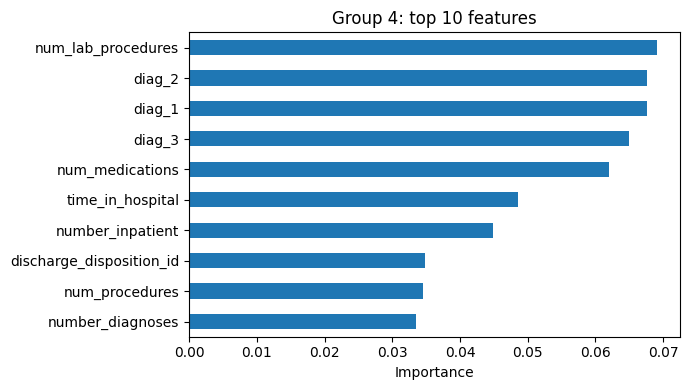

Top three: num_lab_procedures, diag_2, diag_1


In [31]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
imp[::-1].plot(kind="barh", figsize=(7, 4), title=f"Group {GROUP}: top 10 features")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print("Top three:", ", ".join(imp.index[:3]))

## Step 4: Ethics check, does the model work equally well for everyone?
Record recall for each subgroup. A big gap means one group of patients gets missed more often.

**TRY IT:** In Step 2, set `DROP_SENSITIVE = True`, rerun Steps 2 to 4, and see whether removing the column closes the gap.

In [25]:
def subgroup_series(cfg):
    col = cfg["subgroup"]
    if col is None or col not in X_raw.columns:
        return None
    s = X_raw[col].replace("?", np.nan)
    if col == "age":
        num = pd.to_numeric(s, errors="coerce")
        cut = 35 if GROUP == 6 else 60
        return np.where(num.isna(), "not recorded", np.where(num < cut, f"under {cut}", f"{cut} and over"))
    if col == "sex" and set(pd.to_numeric(s, errors="coerce").dropna().unique()) <= {0, 1}:
        return pd.to_numeric(s, errors="coerce").map({1: "male (coded 1)", 0: "female (coded 0)"}).values
    return s.fillna("not recorded").astype(str).values

groups = subgroup_series(cfg)
if groups is None:
    print("This dataset has no demographic column at all.")
    print("Ethics question for your group: who is missing, and how would you even know?")
else:
    g_test = pd.Series(groups[idx_test])
    rows = []
    for g in g_test.unique():
        m = (g_test == g).values
        if m.sum() < 10: continue
        rows.append(dict(subgroup=g, test_patients=int(m.sum()), positive_cases=int(y_test[m].sum()),
                         accuracy=accuracy_score(y_test[m], preds[m]),
                         recall=recall_score(y_test[m], preds[m], zero_division=0)))
    table = pd.DataFrame(rows).sort_values("test_patients", ascending=False)
    print(table.to_string(index=False, formatters={"accuracy": "{:.1%}".format, "recall": "{:.1%}".format}))
    print(f"\nRecall gap between subgroups: {table.recall.max() - table.recall.min():.1%}")

       subgroup  test_patients  positive_cases accuracy recall
      Caucasian           4477             497    88.9%   0.0%
AfricanAmerican           1154             146    87.3%   0.0%
   not recorded            130               8    93.8%   0.0%
       Hispanic             98              16    83.7%   0.0%
          Other             93               5    94.6%   0.0%
          Asian             48               4    91.7%   0.0%

Recall gap between subgroups: 0.0%


## Step 5: Security check, data poisoning attack
An attacker who can edit training labels changes the model without touching its code. This is an **integrity** attack.

- **Random poisoning:** labels are flipped at random.
- **Targeted poisoning:** the attacker relabels sick patients as healthy, so the model learns to miss them.

Record recall at 0%, 10%, and 30% for both attacks.

**TRY IT:** change `POISON_RATES` to test other levels.

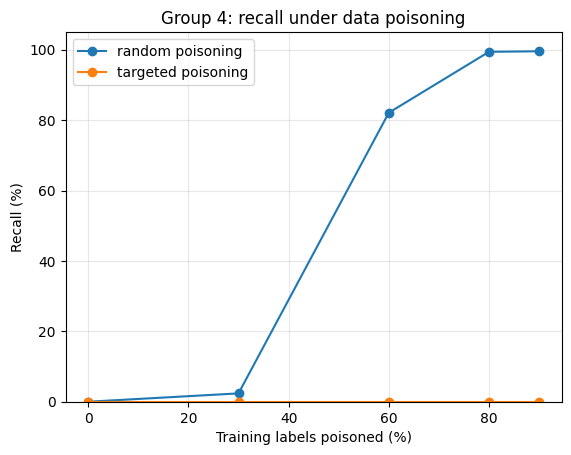

attack random targeted
rate                  
0.0      0.0%     0.0%
0.3      2.4%     0.0%
0.6     82.1%     0.0%
0.8     99.4%     0.0%
0.9     99.6%     0.0%


In [27]:
POISON_RATES = [0.0, 0.3, 0.6, 0.8, 0.9]   # TRY IT

rng = np.random.default_rng(325)
results = []
for rate in POISON_RATES:
    for kind in ["random", "targeted"]:
        yp = y_train.copy()
        pool = np.arange(len(yp)) if kind == "random" else np.where(yp == 1)[0]
        flip = rng.choice(pool, size=int(rate * len(pool)), replace=False)
        yp[flip] = 1 - yp[flip]
        _, _, s = train_and_score(X_train, yp)
        results.append(dict(rate=rate, attack=kind, **s))
res = pd.DataFrame(results)
for kind, g in res.groupby("attack"):
    plt.plot(g.rate * 100, g.recall * 100, marker="o", label=f"{kind} poisoning")
plt.xlabel("Training labels poisoned (%)"); plt.ylabel("Recall (%)"); plt.ylim(0, 105)
plt.title(f"Group {GROUP}: recall under data poisoning"); plt.legend(); plt.grid(alpha=0.3); plt.show()
print(res.pivot(index="rate", columns="attack", values="recall").map("{:.1%}".format).to_string())

## Step 6: Privacy check, how unique is each patient?
Even without names, a rare combination of details can point to one person. Record how many patients share their combination with fewer than 5 others.

In [28]:
quasi = [c for c in cfg["quasi"] if c in X_raw.columns]
if not quasi:
    print("No demographic quasi identifiers in this dataset. Discuss: is that good for privacy, bad for fairness testing, or both?")
else:
    combo = X_raw[quasi].apply(lambda row: " | ".join(map(str, row)), axis=1)
    sizes = combo.map(combo.value_counts())
    print("Quasi identifiers checked:", ", ".join(quasi))
    print(f"Smallest group sharing the same values (k): {sizes.min()}")
    print(f"Patients in a group smaller than 5: {(sizes < 5).sum():,} of {len(sizes):,} ({(sizes < 5).mean():.1%})")

Quasi identifiers checked: race, gender, age
Smallest group sharing the same values (k): 1
Patients in a group smaller than 5: 43 of 20,000 (0.2%)


## Step 7: Ask an AI to interpret your results, then check it
Run this cell, copy the printed prompt into a free chatbot (Gemini, ChatGPT, Claude, or Copilot), and read the answer.

Record one claim the AI got right and one claim you could not verify or think is wrong. Disclose the tool you used on your worksheet.

In [29]:
top3 = ", ".join(imp.index[:3])
rec = res.pivot(index="rate", columns="attack", values="recall")
print(f"""I am a cybersecurity student. A random forest model predicts "{cfg['positive_label']}" in a public, de-identified health dataset ({cfg['name']}).
Baseline results: accuracy {base['accuracy']:.0%}, recall {base['recall']:.0%}, precision {base['precision']:.0%}.
Top features: {top3}.
With 30% targeted label poisoning, recall became {rec.loc[min(rec.index, key=lambda r: abs(r - 0.3)), 'targeted']:.0%}.
1. Explain these results in plain language for a hospital leader.
2. Name the biggest ethical risk and the biggest security risk of deploying this model.
3. Recommend one control for each risk.""")

I am a cybersecurity student. A random forest model predicts "readmitted within 30 days" in a public, de-identified health dataset (Hospital readmission).
Baseline results: accuracy 89%, recall 0%, precision 0%.
Top features: num_lab_procedures, diag_2, diag_1.
With 30% targeted label poisoning, recall became 0%.
1. Explain these results in plain language for a hospital leader.
2. Name the biggest ethical risk and the biggest security risk of deploying this model.
3. Recommend one control for each risk.
